<a href="https://colab.research.google.com/github/ddoneu/ECON3916-Statistical-Machine-Learning/blob/main/Project1/Project_1_Phase_2%263%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHASE 2:

#Step 2.1: Establishing the "Digital Portfolio"


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [16]:
url = 'https://raw.githubusercontent.com/ddoneu/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/lakisha.csv'
df = pd.read_csv(url)

# Step 2.2: Ingestion and "Dirty Data" Forensics


Task 1: Manually clean the Data

In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   education             4870 non-null   int64  
 1   n_jobs                4870 non-null   int64  
 2   years_exp             4870 non-null   int64  
 3   honors                4870 non-null   int64  
 4   volunteer             4870 non-null   int64  
 5   military              4870 non-null   int64  
 6   emp_holes             4870 non-null   int64  
 7   occup_specific        4870 non-null   int64  
 8   occup_broad           4870 non-null   int64  
 9   work_in_school        4870 non-null   int64  
 10  email                 4870 non-null   int64  
 11  computer_skills       4870 non-null   int64  
 12  special_skills        4870 non-null   int64  
 13  first_name            4870 non-null   object 
 14  sex                   4870 non-null   object 
 15  race                 

,education,n_jobs,years_exp,honors,volunteer,military,emp_holes,occup_specific,occup_broad,work_in_school,...,educ_req,comp_req,org_req,manuf,trans_com,bank_real,trade,bus_service,oth_service,miss_ind
count,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,...,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000,4870.000000
mean,3.618480,3.661396,7.842916,0.052772,0.411499,0.097125,0.448049,215.637782,3.481520,0.559548,...,0.106776,0.437166,0.072690,0.082957,0.030390,0.085010,0.213963,0.267762,0.154825,0.165092
std,0.714997,1.219126,5.044612,0.223601,0.492156,0.296159,0.497345,148.127551,2.038036,0.496492,...,0.308860,0.496087,0.259654,0.275845,0.171676,0.278926,0.410143,0.442838,0.361775,0.371302
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,5.000000,0.000000,0.000000,0.000000,0.000000,27.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,267.000000,4.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,4.000000,9.000000,0.000000,1.000000,0.000000,1.000000,313.000000,6.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,4.000000,7.000000,44.000000,1.000000,1.000000,1.000000,1.000000,903.000000,6.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


I dont find any dollar signs or symbols to clean, no wrong data types on key variables by running info and describe. However, 'race' and 'sex' are intentional strings ('b'/'w' and 'f'/'m') so I will create dummies and convert them to binary

In [18]:
# Convert string categoricals to numeric dummies:

df['black']  = (df['race'] == 'b').astype(int)
df['female'] = (df['sex']  == 'f').astype(int)

print(df[['race', 'black', 'sex', 'female']])

     race  black sex  female
0       w      0   f       1
1       w      0   f       1
2       b      1   f       1
3       b      1   f       1
4       w      0   f       1
...   ...    ...  ..     ...
4865    b      1   f       1
4866    b      1   f       1
4867    w      0   m       0
4868    b      1   f       1
4869    w      0   f       1

[4870 rows x 4 columns]


Task 2: Missing Value Strategy (MCAR vs. MAR)

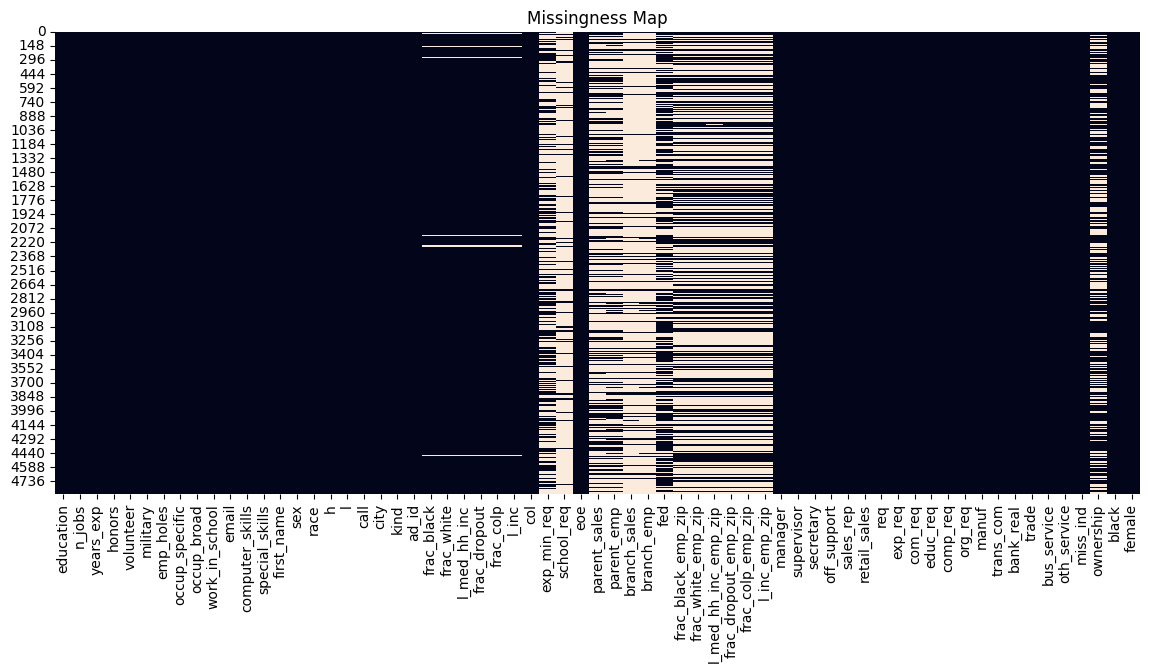

,missing_count,missing_percent
call,0,0.0
race,0,0.0
h,0,0.0
col,0,0.0
sex,0,0.0


,missing_count,missing_percent
school_req,4350,89.322382
branch_sales,4262,87.515400
branch_emp,4212,86.488706
parent_sales,3198,65.667351
parent_emp,3148,64.640657
...,...,...
trade,0,0.000000
oth_service,0,0.000000
miss_ind,0,0.000000
black,0,0.000000


In [19]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missingness Map")
plt.show()

missing_table = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values('missing_percent', ascending=False)

key_vars = ['call', 'race', 'h', 'col', 'sex']
display(missing_table.loc[key_vars])

display(missing_table)

Nothing is missing in the variables I picked

# Step 2.3: Exploratory Data Analysis (EDA) as Visual Forensics


/tmp/ipykernel_14290/3677125680.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='call', data=df, palette=['red','blue'])


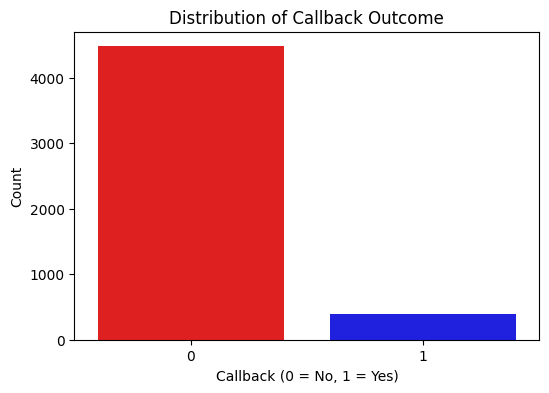

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='call', data=df, palette=['red','blue'])
plt.title("Distribution of Callback Outcome")
plt.xlabel("Callback (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

***NOTE:

'call' is a binary indicator (0/1). Log transformation is not applicable.

Log-normal check is not required for binary dependent variables

/tmp/ipykernel_14290/2236811175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=callback_rate, x='race', y='call', palette=['black','grey'])


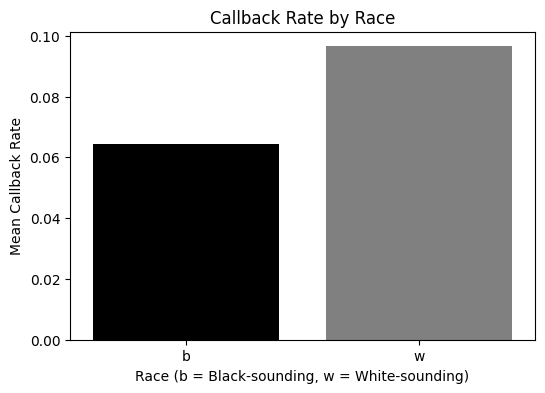

***


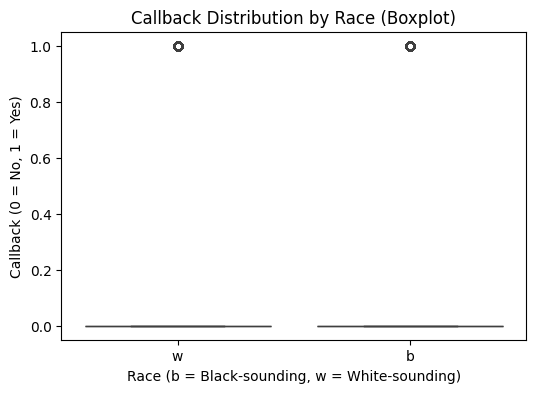

In [21]:
# Since the data is binary, sns.regplot and sns.boxplot wont give a clear visual

# Barplot: mean callback by race
callback_rate = df.groupby('race', as_index=False)['call'].mean()

plt.figure(figsize=(6,4))
sns.barplot(data=callback_rate, x='race', y='call', palette=['black','grey'])
plt.title("Callback Rate by Race")
plt.xlabel("Race (b = Black-sounding, w = White-sounding)")
plt.ylabel("Mean Callback Rate")
plt.show()

print('***')

# Assignment ask for boxplot so I include it here
plt.figure(figsize=(6, 4))
sns.boxplot(x='race', y='call', data=df)
plt.title("Callback Distribution by Race (Boxplot)")
plt.xlabel("Race (b = Black-sounding, w = White-sounding)")
plt.ylabel("Callback (0 = No, 1 = Yes)")
plt.show()

Lower bound: -1.0
Upper bound: 15.0
Number of outliers: 431


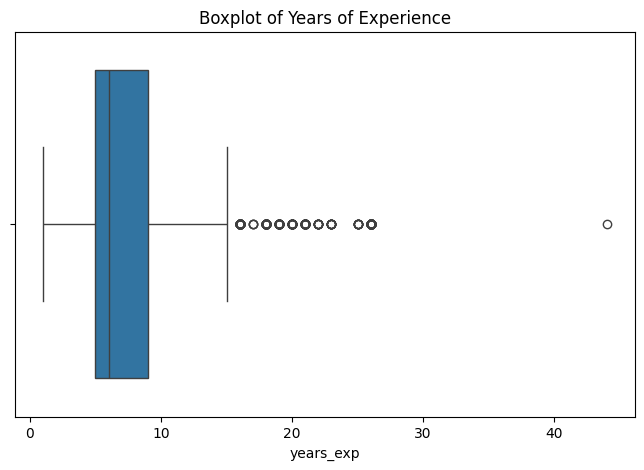

In [22]:
# STEP 2.3C | Outlier Detection — Tukey Fence (IQR x 1.5)
Q1 = df['years_exp'].quantile(0.25)
Q3 = df['years_exp'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['years_exp'] < lower) | (df['years_exp'] > upper)]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", outliers.shape[0])

plt.figure(figsize=(8,5))
sns.boxplot(x=df['years_exp'])
plt.title("Boxplot of Years of Experience")
plt.show()

#PHASE 3:

#Step 3.1: The Baseline Model (OLS Implementation)


In [23]:
import statsmodels.formula.api as smf

formula_1 = 'call ~ black + h + col + female'

model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   call   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.139
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           0.000395
Time:                        20:23:55   Log-Likelihood:                -560.04
No. Observations:                4870   AIC:                             1130.
Df Residuals:                    4865   BIC:                             1163.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0855      0.013      6.489      0.0

# STEP 3.2 | Interaction Term — black × h


In [24]:
formula_2 = 'call ~ black * h + col + female'

model_2 = smf.ols(formula=formula_2, data=df).fit(cov_type='HC1')

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   call   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.184
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           0.000853
Time:                        20:23:55   Log-Likelihood:                -559.39
No. Observations:                4870   AIC:                             1131.
Df Residuals:                    4864   BIC:                             1170.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0811      0.014      5.954      0.0

**Baseline Model:** Holding resume quality and applicant characteristics constant, a Black-sounding name is associated with a 3.2 percentage point lower probability of callback, ceteris paribus. Because call is binary, this specification is a linear probability model, so coefficients are interpreted in percentage points.

**LPM Limitations:** As a Linear Probability Model, this specification can
theoretically predict probabilities outside [0, 1]. However, given the low
baseline callback rate (~8%), predicted values remain within plausible bounds
for this dataset. A Logit model is run below as a robustness check.

**Interaction Model:** The coefficient on black × h is statistically insignificant, which suggests the callback effect of a higher-quality resume does not differ significantly between Black- and White-sounding names. In other words, I do not find evidence that resume quality meaningfully reduces the racial callback gap.

**Omitted Variable Bias:** A relevant omitted variable is employer-level racial
attitudes. However, because names were randomly assigned to identical resumes,
firm-level confounders are orthogonal to treatment by design. Random assignment
neutralizes this bias, the same firms received both Black, and White-sounding
resumes in equal proportions.

Added as recommendation

In [25]:
# STEP 3.3: Robustness Check — Logit Model
formula_logit = 'call ~ black + h + col + female'

model_logit = smf.logit(formula=formula_logit, data=df).fit(cov_type='HC1')
print(model_logit.summary())

# Marginal effects (converts to percentage points for comparison with LPM)
print(model_logit.get_margeff().summary())

Optimization terminated successfully.
         Current function value: 0.277774
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   call   No. Observations:                 4870
Model:                          Logit   Df Residuals:                     4865
Method:                           MLE   Df Model:                            4
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                0.007848
Time:                        20:23:55   Log-Likelihood:                -1352.8
converged:                       True   LL-Null:                       -1363.5
Covariance Type:                  HC1   LLR p-value:                 0.0002635
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3947      0.180    -13.272      0.000      -2.748      -2.041
black         -0.4395      0.

## Logit Robustness Check

The Logit marginal effects closely mirror the LPM coefficients:

- **black:** LPM = -0.0320 vs. Logit = -0.0324 (virtually identical)
- **h:** LPM = 0.0141 vs. Logit = 0.0141 (identical)
- **col:** LPM = -0.0035 vs. Logit = -0.0034 (identical)
- **female:** LPM = 0.0084 vs. Logit = 0.0087 (virtually identical)

The LPM and Logit produce substantively identical results, confirming that
the linear probability model is a valid and interpretable specification for
this dataset. The racial callback penalty of ~3.2 percentage points is robust
across both functional forms.


#PHASE 4

In [60]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

#Step 4.1: Model Execution (Your Proposed Causal Strategy)


In [61]:
vars_of_interest = ['call', 'h', 'col', 'female', 'years_exp', 'n_jobs']

table1 = df.groupby('race')[vars_of_interest].mean().T
table1.columns = ['Black-Sounding', 'White-Sounding']
table1['Difference'] = table1['White-Sounding'] - table1['Black-Sounding']

n_black = (df['black'] == 1).sum()
n_white = (df['black'] == 0).sum()

print("Table 1: Summary Statistics by Perceived Race")
print(f"Treatment (Black-sounding): n = {n_black} | Control (White-sounding): n = {n_white}")
print(table1.round(4))

Table 1: Summary Statistics by Perceived Race
Treatment (Black-sounding): n = 2435 | Control (White-sounding): n = 2435
           Black-Sounding  White-Sounding  Difference
call               0.0645          0.0965      0.0320
h                  0.5023          0.5023      0.0000
col                0.7228          0.7162     -0.0066
female             0.7745          0.7639     -0.0107
years_exp          7.8296          7.8563      0.0267
n_jobs             3.6583          3.6645      0.0062


In [62]:
# Identification: random name assignment on audit resumes
# HC1 robust SE used throughout

# Model 1: Baseline — race signal only
model_1 = smf.ols('call ~ black', data=df).fit(cov_type='HC1')

# Model 2: Multivariate — race + full resume controls
model_2 = smf.ols(
    'call ~ black + h + col + female + years_exp + n_jobs',
    data=df
).fit(cov_type='HC1')

# Model 3: Interaction — does resume quality moderate the racial gap?
model_3 = smf.ols(
    'call ~ black * h + col + female + years_exp + n_jobs',
    data=df
).fit(cov_type='HC1')

print("\n=== Model 1: Baseline ===")
print(model_1.summary())
print("\n=== Model 2: Multivariate ===")
print(model_2.summary())
print("\n=== Model 3: Interaction ===")
print(model_3.summary())


=== Model 1: Baseline ===
                            OLS Regression Results                            
Dep. Variable:                   call   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     16.93
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           3.94e-05
Time:                        21:04:38   Log-Likelihood:                -562.24
No. Observations:                4870   AIC:                             1128.
Df Residuals:                    4868   BIC:                             1141.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0965    

In [63]:
#TABLE 2: PROFESSIONAL REGRESSION TABLE
table2 = summary_col(
    [model_1, model_2, model_3],
    stars=True,
    float_format='%0.4f',
    model_names=['Model 1\nBaseline', 'Model 2\nMultivariate', 'Model 3\nInteraction'],
    info_dict={'N': lambda x: f"{int(x.nobs)}"}
)

print("\nTable 2: OLS Regression Results — Dependent Variable: Callback (0/1)")
print("HC1 Heteroscedasticity-Robust Standard Errors in parentheses")
print(table2)


Table 2: OLS Regression Results — Dependent Variable: Callback (0/1)
HC1 Heteroscedasticity-Robust Standard Errors in parentheses

                Model 1     Model 2      Model 3  
                Baseline  Multivariate Interaction
--------------------------------------------------
Intercept      0.0965***  0.0755***    0.0712***  
               (0.0060)   (0.0182)     (0.0183)   
black          -0.0320*** -0.0320***   -0.0230**  
               (0.0078)   (0.0078)     (0.0106)   
h                         0.0139*      0.0229*    
                          (0.0082)     (0.0124)   
col                       -0.0006      -0.0007    
                          (0.0093)     (0.0093)   
female                    0.0063       0.0063     
                          (0.0094)     (0.0094)   
years_exp                 0.0035***    0.0035***  
                          (0.0009)     (0.0009)   
n_jobs                    -0.0049      -0.0049    
                          (0.0038)     (0.0038)   
b

# Step 4.2: Model Diagnostics (Validating Assumptions)

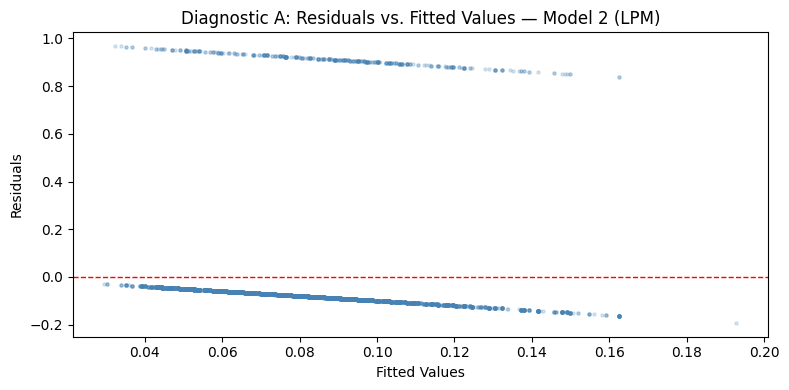

In [64]:
# Diagnostic A: Residuals vs. Fitted Values
# Checks for heteroscedasticity — expected two-band pattern in LPM

fitted = model_2.fittedvalues
residuals = model_2.resid

plt.figure(figsize=(8, 4))
plt.scatter(fitted, residuals, alpha=0.2, s=5, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Diagnostic A: Residuals vs. Fitted Values — Model 2 (LPM)')
plt.tight_layout()
plt.show()

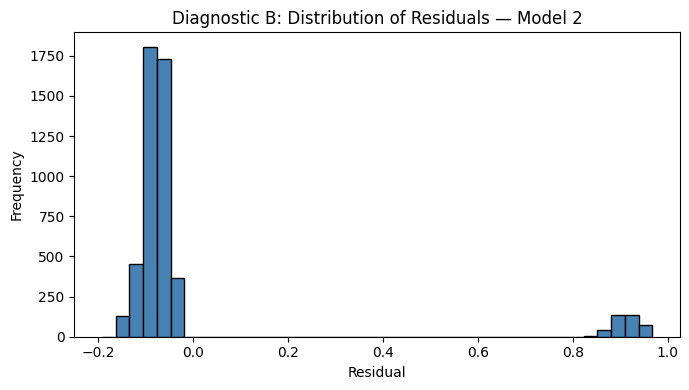

In [65]:
# Diagnostic B: Distribution of Residuals
# Checks for skewness — expected bimodal pattern with binary outcome

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color='steelblue', edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Diagnostic B: Distribution of Residuals — Model 2')
plt.tight_layout()
plt.show()


In [66]:
# Diagnostic C: Covariate Balance Test
# Purpose: method-specific check — validates exogeneity of 'black' under RCT

covariates = ['h', 'col', 'female', 'years_exp', 'n_jobs']
black_group = df[df['black'] == 1]
white_group = df[df['black'] == 0]

print("Diagnostic C: Covariate Balance Test")
print("Null hypothesis: no difference in means between treatment and control")
print()
print(f"{'Variable':<12} {'Black Mean':>12} {'White Mean':>12} "
      f"{'Difference':>12} {'p-value':>10}")
print("-" * 62)

for var in covariates:
    b_mean = black_group[var].mean()
    w_mean = white_group[var].mean()
    diff = w_mean - b_mean
    t_stat, p_val = stats.ttest_ind(
        white_group[var],
        black_group[var],
        equal_var=False
    )
    sig = ""
    if p_val < 0.01:
        sig = "***"
    elif p_val < 0.05:
        sig = "**"
    elif p_val < 0.10:
        sig = "*"
    print(f"{var:<12} {b_mean:>12.4f} {w_mean:>12.4f} "
          f"{diff:>12.4f} {p_val:>9.4f}{sig}")

print()
print("\nResult: No significant imbalance detected (all p > 0.10)")
print("This is consistent with successful random assignment and supports the exogeneity of 'black'.")

Diagnostic C: Covariate Balance Test
Null hypothesis: no difference in means between treatment and control

Variable       Black Mean   White Mean   Difference    p-value
--------------------------------------------------------------
h                  0.5023       0.5023       0.0000    1.0000
col                0.7228       0.7162      -0.0066    0.6099
female             0.7745       0.7639      -0.0107    0.3767
years_exp          7.8296       7.8563       0.0267    0.8535
n_jobs             3.6583       3.6645       0.0062    0.8601


Result: No significant imbalance detected (all p > 0.10)
This is consistent with successful random assignment and supports the exogeneity of 'black'.


In [68]:
# Diagnostic D: Outlier Robustness Check
# Drops 431 outliers (years_exp > 15) identified via Tukey fence in Phase 2

df_trim = df[df['years_exp'] <= 15].copy()

print(f"\nFull sample:          n = {len(df)}")
print(f"Trimmed sample:       n = {len(df_trim)}")
print(f"Observations dropped: n = {len(df) - len(df_trim)}")

model_2_trim = smf.ols(
    'call ~ black + h + col + female + years_exp + n_jobs',
    data=df_trim
).fit(cov_type='HC1')

table3 = summary_col(
    [model_2, model_2_trim],
    stars=True,
    float_format='%0.4f',
    model_names=['Model 2\nFull Sample', 'Model 2\nTrimmed (exp≤15)'],
    info_dict={'N': lambda x: f"{int(x.nobs)}"}
)

print("\nTable 3: Robustness Check — Outlier Sensitivity")
print("Dependent Variable: Callback (0/1) | HC1 Robust SE")
print(table3)


Full sample:          n = 4870
Trimmed sample:       n = 4439
Observations dropped: n = 431

Table 3: Robustness Check — Outlier Sensitivity
Dependent Variable: Callback (0/1) | HC1 Robust SE

                 Model 2       Model 2     
               Full Sample Trimmed (exp≤15)
-------------------------------------------
Intercept      0.0755***   0.0759***       
               (0.0182)    (0.0194)        
black          -0.0320***  -0.0316***      
               (0.0078)    (0.0079)        
h              0.0139*     0.0113          
               (0.0082)    (0.0083)        
col            -0.0006     0.0076          
               (0.0093)    (0.0094)        
female         0.0063      0.0001          
               (0.0094)    (0.0098)        
years_exp      0.0035***   0.0041***       
               (0.0009)    (0.0014)        
n_jobs         -0.0049     -0.0063         
               (0.0038)    (0.0040)        
R-squared      0.0082      0.0065          
R-squared Adj.